# User-Based Collaborative Filtering Movie Recommendation System (PySpark)

---

## Project Overview

This project implements a User-Based Collaborative Filtering Recommendation System using PySpark.  
It predicts movie ratings and recommends movies to users based on user–user similarity computed through cosine similarity or Pearson correlation.

### Dataset Used
MovieLens dataset (from GitHub repo:  
[https://github.com/sankalpjain99/Movie-recommendation-system.git](https://github.com/sankalpjain99/Movie-recommendation-system.git))

Files:
- ratings.csv – userId, movieId, rating, timestamp  
- movies.csv – movieId, title, genres  
- links.csv – movieId, imdbId, tmdbId  
- tags.csv – userId, movieId, tag, timestamp



# Initialize Spark and Load Data

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct, count

spark = (SparkSession.builder
         .appName("UserCF-Recommender")
         .master("local[*]")
         .getOrCreate())

ratings = (spark.read
           .option("header", True)
           .option("inferSchema", True)
           .csv("data/ratings.csv")
           .select("userId", "movieId", "rating"))

movies  = (spark.read
           .option("header", True)
           .option("inferSchema", True)
           .csv("data/movies.csv")
           .select("movieId", "title", "genres"))

links   = (spark.read
           .option("header", True)
           .option("inferSchema", True)
           .csv("data/links.csv"))


In [ ]:
result = ratings.agg(
    F.min("rating").alias("min_value"),
    F.max("rating").alias("max_value")
)

result.show()

+---------+---------+
|min_value|max_value|
+---------+---------+
|      0.5|      5.0|
+---------+---------+



# Basic Statistics

In [ ]:
stats = ratings.agg(
    countDistinct("userId").alias("n_users"),
    countDistinct("movieId").alias("n_movies"),
    count("*").alias("n_ratings")
)
stats.show()


+-------+--------+---------+
|n_users|n_movies|n_ratings|
+-------+--------+---------+
|    610|    9724|   100836|
+-------+--------+---------+



# User Item Matrix

In [ ]:
from pyspark.sql.functions import first
user_item_matrix = (ratings
    .groupBy("userId")
    .pivot("movieId")
    .agg(first("rating")))

user_item_matrix.show(5)


# Similarity Computation (User to User)

### user mean ratings

In [ ]:
from pyspark.sql.functions import avg

user_mean = ratings.groupBy("userId").agg(avg("rating").alias("user_mean"))
ratings_centered = (ratings
    .join(user_mean, on="userId", how="inner")
    .withColumn("rating_centered", col("rating") - col("user_mean"))
    .select("userId", "movieId", "rating_centered"))


### user–user pairs via co-rated movies

In [ ]:
r1 = ratings_centered.select(
    col("userId").alias("u"),
    col("movieId").alias("movieId"),
    col("rating_centered").alias("rui")
)

r2 = ratings_centered.select(
    col("userId").alias("v"),
    col("movieId").alias("movieId"),
    col("rating_centered").alias("rvi")
)

pairs = (r1.join(r2, on="movieId")
           .where(col("u") < col("v")))  # avoid duplicates and self-pairs


### Aggregate to cosine similarity:
cosine(u,v)

Specifically Pearson (Mean Centered Cosine Similarity)



In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import sum as spark_sum, sqrt, col, lit, count

eps = 1e-9

# Center ratings by user mean
ratings_centered = (
    ratings.join(user_mean, on="userId")
           .withColumn("r_centered", col("rating") - col("user_mean"))
)

# Create all user-user pairs on same movie
pairs = (ratings_centered.alias("r1")
    .join(ratings_centered.alias("r2"),
          (F.col("r1.movieId") == F.col("r2.movieId")) &
          (F.col("r1.userId") < F.col("r2.userId")))  # avoid duplicates
    .select(
        F.col("r1.userId").alias("u"),
        F.col("r2.userId").alias("v"),
        F.col("r1.r_centered").alias("rui"),
        F.col("r2.r_centered").alias("rvi")
    )
)

# Compute Pearson (mean-centered cosine)
sim = (pairs
    .groupBy("u", "v")
    .agg(
        spark_sum(col("rui") * col("rvi")).alias("num"),
        sqrt(spark_sum(col("rui") * col("rui"))).alias("den_u"),
        sqrt(spark_sum(col("rvi") * col("rvi"))).alias("den_v"),
        count("*").alias("n_common")
    )
    .withColumn("sim", col("num") / (col("den_u") * col("den_v") + lit(eps)))
    .withColumn("sim", F.when(col("sim") > 1, 1)
                        .when(col("sim") < -1, -1)
                        .otherwise(col("sim")))
)

# Make symmetric
sim_sym = (
    sim.select(col("u").alias("user1"), col("v").alias("user2"), "sim", "n_common")
       .unionByName(sim.select(col("v").alias("user1"), col("u").alias("user2"), "sim", "n_common")))


example

In [ ]:
# pick a small set of users to display
sample_users = [10, 20, 30, 40, 50]

sim_sample = (sim_sym
    .filter(col("user1").isin(sample_users) & col("user2").isin(sample_users))
    .orderBy("user1", "user2"))

sim_sample.show(50, truncate=False)


+-----+-----+--------------------+--------+
|user1|user2|sim                 |n_common|
+-----+-----+--------------------+--------+
|10   |20   |0.2885197427286932  |12      |
|10   |30   |0.1083800370507437  |10      |
|10   |40   |-0.8807263839335178 |2       |
|10   |50   |-0.21310240235712877|23      |
|20   |10   |0.2885197427286932  |12      |
|20   |30   |0.9999999986594983  |2       |
|20   |40   |-0.24082354437139974|10      |
|20   |50   |0.09709471643732787 |22      |
|30   |10   |0.1083800370507437  |10      |
|30   |20   |0.9999999986594983  |2       |
|30   |40   |0.8261115773971203  |2       |
|30   |50   |-0.1839098190865725 |11      |
|40   |10   |-0.8807263839335178 |2       |
|40   |20   |-0.24082354437139974|10      |
|40   |30   |0.8261115773971203  |2       |
|40   |50   |0.8985360176309931  |5       |
|50   |10   |-0.21310240235712877|23      |
|50   |20   |0.09709471643732787 |22      |
|50   |30   |-0.1839098190865725 |11      |
|50   |40   |0.8985360176309931 

# Rating Prediction based on similarity : target user = 10

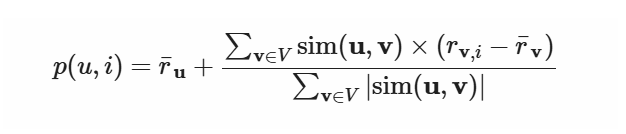

### views

In [ ]:
ratings.createOrReplaceTempView("ratings")
user_mean.createOrReplaceTempView("user_mean")
sim_sym.createOrReplaceTempView("sim")
movies.createOrReplaceTempView("movies")


### Predict ratings for all unseen movies of a given user

neighbours >= 20

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import abs as spark_abs, when, lit, sum as ssum, count, col

target_user = 10
eps = 1e-6  # small stabilizer to prevent division by zero
min_neighbors = 20  # require at least 20 neighbors for stability


#  Movies target user has already rated

seen = (
    ratings.filter(col("userId") == target_user)
           .select("movieId")
           .distinct()
)

# Candidate movies (not yet rated by target user)
candidates = (
    movies.join(seen, on="movieId", how="left_anti")
          .select("movieId")
)

# Gather neighbors who rated candidate movies

neighbors = (
    ratings.alias("r")
    .join(user_mean.alias("um_v"), col("r.userId") == col("um_v.userId"))
    .join(candidates, on="movieId")
    .select(
        col("r.userId").alias("v"),
        col("r.movieId").alias("movieId"),
        col("r.rating").alias("rv_i"),
        col("um_v.user_mean").alias("mu_v")
    )
)

#  Similarities for the target user

sims_u = (
    sim_sym.filter(col("user1") == target_user)
           .select(col("user2").alias("v"), col("sim").alias("sim_uv"))
)

# Combine neighbor ratings with similarity weights
neigh_with_sim = (
    neighbors.join(sims_u, on="v", how="inner")
)

# Keep only positively correlated users (recommended for cosine)
neigh_with_sim = neigh_with_sim.filter(col("sim_uv") > 0)


# Target user’s mean rating

mu_u = (
    user_mean.filter(col("userId") == target_user)
             .select("user_mean")
             .first()[0]
)

# Predict ratings for candidate movies

preds = (
    neigh_with_sim
    .withColumn("num_term", col("sim_uv") * (col("rv_i") - col("mu_v")))
    .withColumn("den_term", spark_abs(col("sim_uv")))
    .groupBy("movieId")
    .agg(
        ssum("num_term").alias("num"),
        ssum("den_term").alias("den"),
        count("*").alias("n_neighbors")
    )
    .filter(col("n_neighbors") >= min_neighbors)  # require enough neighbors
    .withColumn("pred", lit(mu_u) + col("num") / (col("den") + eps))
    .orderBy(col("pred").desc())
)

# Ensure numeric column type
preds = preds.withColumn("pred", col("pred").cast("double"))


# Join movie titles for readability

preds_with_titles = (
    preds.join(movies.select("movieId", "title"), on="movieId", how="left")
         .orderBy(F.col("pred").desc())
)

# Display top 10 recommendations
preds_with_titles.show(10, truncate=False)


+-------+------------------+------------------+-----------+------------------+----------------------------------------------------------------------------------------------+
|movieId|num               |den               |n_neighbors|pred              |title                                                                                         |
+-------+------------------+------------------+-----------+------------------+----------------------------------------------------------------------------------------------+
|750    |4.484776186120555 |6.714515733852189 |25         |3.946493836674147 |Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)                   |
|260    |15.332995061055417|23.683103453232036|70         |3.925994788601533 |Star Wars: Episode IV - A New Hope (1977)                                                     |
|318    |21.71101387281138 |36.460540725310665|99         |3.874037454182884 |Shawshank Redemption, The (1994)                    

# Recommendation Generation

## Looking up liked movie

In [ ]:
inception = (movies
    .filter(col("title").like("%Inception%"))
    .select("movieId", "title")
    .orderBy("movieId"))
inception.show(truncate=False)


+-------+----------------+
|movieId|title           |
+-------+----------------+
|79132  |Inception (2010)|
+-------+----------------+



## Top 5 recommendation for the target user

In [ ]:
top5 = preds_with_titles.limit(5)
top5.show(truncate=False)


+-------+------------------+------------------+-----------+------------------+---------------------------------------------------------------------------+
|movieId|num               |den               |n_neighbors|pred              |title                                                                      |
+-------+------------------+------------------+-----------+------------------+---------------------------------------------------------------------------+
|750    |4.484776186120555 |6.714515733852189 |25         |3.946493836674147 |Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)|
|260    |15.332995061055415|23.683103453232036|70         |3.9259947886015327|Star Wars: Episode IV - A New Hope (1977)                                  |
|318    |21.711013872811375|36.46054072531068 |99         |3.8740374541828837|Shawshank Redemption, The (1994)                                           |
|48516  |4.143561173229973 |6.966129439269437 |24         |3.873386758

## Interpretation

### - The table above shows the predicted ratings for the target user(userId = 10) on unseen movies

### - Predicted ratings are computed using user touser similarities and mean centered ratings.

### - Movies with higher prediction score is more likely to be recommended.


# For Streamlit: Precomputing

In [ ]:
# Compute each user's average rating (mean)
from pyspark.sql.functions import avg

user_mean = ratings.groupBy("userId").agg(avg("rating").alias("mu"))
user_mean.show(5)


+------+------------------+
|userId|                mu|
+------+------------------+
|   148|3.7395833333333335|
|   463| 3.787878787878788|
|   471|             3.875|
|   496| 3.413793103448276|
|   243| 4.138888888888889|
+------+------------------+
only showing top 5 rows



In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import abs as spark_abs, when, lit, sum as ssum, count, col
import os


# Configuration

output_dir = "data/"
os.makedirs(output_dir, exist_ok=True)

eps = 1e-6
target_users = [11, 13, 15, 16]
min_neighbors = 10


# Standardize user_mean column name

if "mu" in user_mean.columns:
    user_mean = user_mean.withColumnRenamed("mu", "user_mean")

ratings.cache()
user_mean.cache()
sim_sym.cache()


# Generate predictions for each user

for target_user in target_users:
    print(f"\n Computing recommendations for user {target_user}...")

    # Movies already rated by this user
    seen = ratings.filter(col("userId") == target_user).select("movieId").distinct()

    # Unseen movies (candidates)
    candidates = movies.join(seen, on="movieId", how="left_anti").select("movieId")

    # Neighbor ratings with their mean
    neighbors = (
        ratings.alias("r")
        .join(user_mean.alias("um_v"), col("r.userId") == col("um_v.userId"))
        .join(candidates, on="movieId")
        .select(
            col("r.userId").alias("v"),
            col("r.movieId").alias("movieId"),
            col("r.rating").alias("rv_i"),
            col("um_v.user_mean").alias("mu_v")
        )
    )

    # Similarities for the target user
    sims_u = (
        sim_sym.filter(col("user1") == target_user)
               .select(col("user2").alias("v"), col("sim").alias("sim_uv"), col("n_common"))
    )

    # Combine neighbor ratings with similarities
    neigh_with_sim = neighbors.join(sims_u, on="v", how="inner")

    # filter out weak or unstable similarities
    neigh_with_sim = neigh_with_sim.filter((col("sim_uv") > 0.1) & (col("n_common") >= 5))

    # Target user's mean rating
    mu_u = (
        user_mean.filter(col("userId") == target_user)
                 .select("user_mean")
                 .first()[0]
    )

    # Compute predictions
    preds = (
        neigh_with_sim
        .withColumn("num_term", col("sim_uv") * (col("rv_i") - col("mu_v")))
        .withColumn("den_term", col("sim_uv"))  # signed sum for Pearson
        .groupBy("movieId")
        .agg(
            ssum("num_term").alias("num"),
            ssum("den_term").alias("den"),
            count("*").alias("n_neighbors")
        )
        .filter(col("n_neighbors") >= min_neighbors)
        .withColumn("pred", lit(mu_u) + col("num") / (col("den") + eps))
        .withColumn(
            "pred",
            when(col("pred") > 5.0, 5.0)
            .when(col("pred") < 0.5, 0.5)
            .otherwise(col("pred"))
        )
        .withColumn("pred", col("pred").cast("double"))
        .orderBy(col("pred").desc())
    )

    # Join with movie details for output
    preds_full = (
        preds.join(movies.select("movieId", "title", "genres"), on="movieId", how="left")
             .join(links.select("movieId", "imdbId", "tmdbId"), on="movieId", how="left")
             .select(
                 "movieId",
                 "num",
                 "den",
                 "pred",
                 "title",
                 "genres",
                 "imdbId",
                 "tmdbId"
             )
             .dropDuplicates(["movieId"])
             .orderBy(F.col("pred").desc())
    )

    # Save as CSV
    preds_pd = preds_full.toPandas()
    file_path = os.path.join(output_dir, f"predictions_user{target_user}.csv")
    preds_pd.to_csv(file_path, index=False)

    print(f"Saved recommendations for user {target_user} → {file_path}")



 Computing recommendations for user 11...
Saved recommendations for user 11 → data/predictions_user11.csv

 Computing recommendations for user 13...
Saved recommendations for user 13 → data/predictions_user13.csv

 Computing recommendations for user 15...
Saved recommendations for user 15 → data/predictions_user15.csv

 Computing recommendations for user 16...
Saved recommendations for user 16 → data/predictions_user16.csv


In [ ]:
import pandas as pd
import glob

for user in [11,13,15,16]:
    file = f"data/predictions_user{user}.csv"

    df = pd.read_csv(file)

    # Sort by predicted rating (highest first)
    df_sorted = df.sort_values(by="pred", ascending=False)

    print(f"\n User {user} — Top 5 Recommended Movies:")
    display(df_sorted[["title", "pred"]].head(5))



 User 11 — Top 5 Recommended Movies:


,title,pred
0,Wallace & Gromit: The Best of Aardman Animatio...,4.892877
1,Paths of Glory (1957),4.817407
2,Dallas Buyers Club (2013),4.711553
3,Patton (1970),4.634092
4,Roman Holiday (1953),4.609091



 User 13 — Top 5 Recommended Movies:


,title,pred
0,"Grand Day Out with Wallace and Gromit, A (1989)",4.780906
1,"Outlaw Josey Wales, The (1976)",4.646700
2,"Shawshank Redemption, The (1994)",4.593233
3,Kelly's Heroes (1970),4.579783
4,Lawrence of Arabia (1962),4.537790



 User 15 — Top 5 Recommended Movies:


,title,pred
0,Hamlet (1996),4.606630
1,Wallace & Gromit: The Best of Aardman Animatio...,4.535653
2,"Grand Day Out with Wallace and Gromit, A (1989)",4.387757
3,Dr. Strangelove or: How I Learned to Stop Worr...,4.373394
4,"Great Escape, The (1963)",4.350842



 User 16 — Top 5 Recommended Movies:


,title,pred
0,Hoop Dreams (1994),4.703638
1,"Player, The (1992)",4.691785
2,Rosemary's Baby (1968),4.668398
3,Heavenly Creatures (1994),4.654754
4,Wallace & Gromit: The Best of Aardman Animatio...,4.651481
